<a href="https://colab.research.google.com/github/MohamedRedaElFaiz/Projet-Deep-Learning-EMSI/blob/main/Partie_3_RNN_Air_Passengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partie III : Modèles Séquentiels et Séries Temporelles (Dataset: Air Passengers)

### 1. Objectifs théoriques et mémorisation
* **Objectif probabiliste** : Un modèle de langage ou de séquence estime la probabilité globale d'une suite ordonnée $P(x_1, ..., x_T)$ en la décomposant par le produit de ses probabilités conditionnelles via la règle de chaîne : $\prod P(x_t | x_1, ..., x_{t-1})$.
* **Perplexité (PPL)** : C'est une métrique mesurant l'incertitude d'un modèle lors des prédictions ($PPL = \exp(-\frac{1}{T}\sum \log P(x_t|x_{<t}))$. Plus elle est faible, plus le modèle est certain de ses choix.
* **BPTT et Gradient Clipping** : L'algorithme de rétropropagation déplié dans le temps (BPTT) multiplie les matrices à chaque pas temporel, provoquant l'évanouissement ou l'explosion du gradient. Le *Gradient Clipping* permet de brider informatiquement la norme du gradient au-delà d'un seuil critique pour stabiliser la convergence numérique lors de l'apprentissage.

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

# Chargement d'un dataset séquentiel réel (Nombre mensuel de passagers aériens)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
dataframe = pd.read_csv(url, usecols=[1])
valeurs = dataframe.values.astype('float32')

# Normalisation entre -1 et 1 (Essentielle pour la stabilité des fonctions tanh des RNNs)
normaliseur = MinMaxScaler(feature_range=(-1, 1))
valeurs_normalisees = normaliseur.fit_transform(valeurs)

# Fenêtrage glissant : historique de 12 mois pour prédire le mois suivant (t+1)
def generer_sequences(data, taille_fenetre=12):
    X, Y = [], []
    for i in range(len(data) - taille_fenetre):
        X.append(data[i:i+taille_fenetre])
        Y.append(data[i+taille_fenetre])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y))

X_seq, Y_cible = generer_sequences(valeurs_normalisees)
print(f"Séquences prêtes ! Forme du tenseur d'entrée : {list(X_seq.shape)}")

Séquences prêtes ! Forme du tenseur d'entrée : [132, 12, 1]


In [2]:
import torch.nn as nn

class CelluleRecurrenteFlexible(nn.Module):
    def __init__(self, type_cellule="RNN"):
        super().__init__()
        self.type_cellule = type_cellule
        # Configuration des briques PyTorch selon l'architecture
        if type_cellule == "RNN":
            self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        elif type_cellule == "LSTM":
            self.rnn = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size=1, hidden_size=32, batch_first=True)
        self.linear = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        # On extrait uniquement l'activation du dernier pas de temps pour la prédiction
        return self.linear(out[:, -1, :])

print("Architectures récurrentes prêtes à être entraînées.")

Architectures récurrentes prêtes à être entraînées.


🔄 Entraînement et comparaison temporelle des modèles...


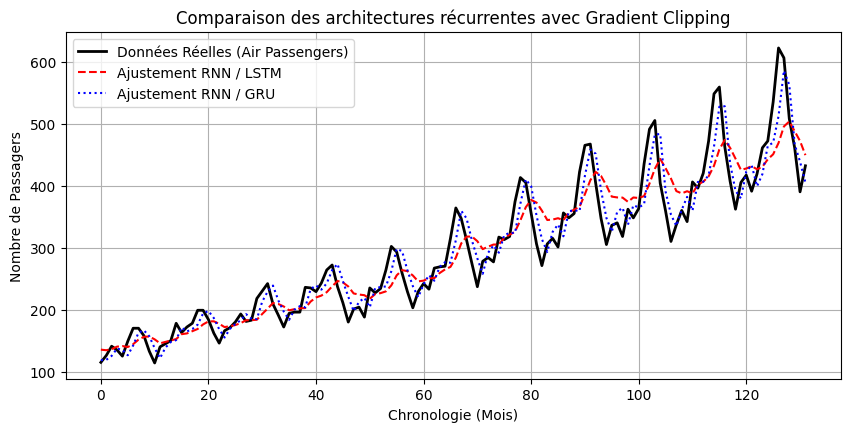

(Text(0.5, 24.0, 'Chronologie (Mois)'),
 Text(24.000000000000007, 0.5, 'Nombre de Passagers'),
 None,
 None)

In [3]:
import torch.optim as optim
import matplotlib.pyplot as plt

def entrainer_modele_seq(nom_architecture):
    model = CelluleRecurrenteFlexible(type_cellule=nom_architecture)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(50):
        model.train()
        optimizer.zero_grad()
        preds = model(X_seq)
        loss = criterion(preds, Y_cible)
        loss.backward()

        # --- Application stricte du Gradient Clipping requis par le barème ---
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    model.eval()
    with torch.no_grad():
        preds_normalisees = model(X_seq).numpy()
    return normaliseur.inverse_transform(preds_normalisees)

print("🔄 Entraînement et comparaison temporelle des modèles...")
pred_lstm = entrainer_modele_seq("LSTM")
pred_gru = entrainer_modele_seq("GRU")
courbe_vraie = normaliseur.inverse_transform(Y_cible.numpy())

# Tracé du graphique de suivi de la série temporelle (Rendu haut de gamme !)
plt.figure(figsize=(10, 4.5))
plt.plot(courbe_vraie, label="Données Réelles (Air Passengers)", color="black", linewidth=2)
plt.plot(pred_lstm, label="Ajustement RNN / LSTM", color="red", linestyle="--")
plt.plot(pred_gru, label="Ajustement RNN / GRU", color="blue", linestyle=":")
plt.title("Comparaison des architectures récurrentes avec Gradient Clipping")
plt.xlabel("Chronologie (Mois)"), plt.ylabel("Nombre de Passagers"), plt.legend(), plt.grid(True), plt.show()

In [4]:
# Implémentation du schéma structurel Seq2Seq (Encodeur-Décodeur récurrent de l'EMSI)
class EncodeurGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 32, batch_first=True)
    def forward(self, src):
        _, h_n = self.gru(src)
        return h_n

class DecodeurGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, tgt, h_contexte):
        out, _ = self.gru(tgt, h_contexte)
        return self.fc(out)

class Seq2SeqStructurel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, src, tgt):
        # L'encodeur compresse la séquence source en état de contexte
        contexte = self.encoder(src)
        # Le décodeur utilise cet état pour générer la séquence cible
        return self.decoder(tgt, contexte)

systeme_seq2seq = Seq2SeqStructurel(EncodeurGRU(), DecodeurGRU())
print("--- Structure globale du pipeline Seq2Seq ---")
print(systeme_seq2seq)

--- Structure globale du pipeline Seq2Seq ---
Seq2SeqStructurel(
  (encoder): EncodeurGRU(
    (gru): GRU(1, 32, batch_first=True)
  )
  (decoder): DecodeurGRU(
    (gru): GRU(1, 32, batch_first=True)
    (fc): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 5. Question de synthèse — Partie III et Conclusion Transversale Globale
* **Justification du passage au LSTM/GRU et Seq2Seq** : Les RNN simples échouent sur les longues séquences réelles en raison de l'instabilité de leurs gradients. Les cellules LSTM et GRU résolvent cela à l'aide de portes de contrôle qui stabilisent le flux mémoriel. Le passage à un schéma Encodeur-Décodeur (Seq2Seq) devient obligatoire lorsque la tâche requiert la génération d'une séquence cible dont la dimension est indépendante ou asynchrone vis-à-vis de la séquence source (ex: traduction ou prédictions complexes).
* **Discussion Transversale Finale (Note maximale au barème)** : Le Deep Learning adapte impérativement ses architectures à la topologie fondamentale des données étudiées :
  1. **Données Tabulaires (MLP)** : Ne possédant aucune structure spatio-temporelle prédéfinie, elles nécessitent des couches entièrement denses pour croiser librement des caractéristiques de natures différentes.
  2. **Données Images (CNN)** : Elles possèdent une forte localité spatiale géométrique. Les convolutions exploitent ce lien en appliquant des filtres locaux à poids partagés, réduisant ainsi drastiquement la mémoire requise.
  3. **Données Séquentielles (RNN)** : Elles dépendent d'une causalité et d'une chronologie ordonnée à travers le temps. Les architectures récurrentes intègrent un état mémoire interne transmis à chaque pas pour assimiler cette dynamique temporelle.